# BGL Log Anomaly Detection: Deep SVDD Pipeline
### (Precision-Improved Version)

### Pipeline 1 — Deep SVDD
**Stage 1 — Deep SVDD (Deep Support Vector Data Description)**
- Trained exclusively on normal logs (50 % of all normal logs)
- Learns a compact hypersphere enclosing normal log embeddings
- Flags any test log whose embedding falls outside the hypersphere as anomalous

**Precision Improvements Applied**
1. **Warm-start centre** — network runs warmup epochs before centre is fixed, avoiding cold-random placement
2. **L2-normalised representations** — unit-sphere output makes distance purely directional, sharpening the boundary
3. **Larger / deeper network** — 256-wide hidden layers, smaller repr dim (32), 40 training epochs
4. **Validation-set threshold calibration** — threshold derived from held-out normal logs (not training distances)
5. **Precision-recall curve threshold selection** — F-beta (β=0.5) maximisation to explicitly weight precision over recall

**Evaluation**
- Traditional binary metrics: Accuracy, Precision, Recall, F1-Score

## Dataset
- Source          : BGL 2k structured log dataset
- Label convention: `'-'` = Normal, any other label = Anomalous
- Deep SVDD train : 50 % of all normal logs
- Validation set  : 200 held-out normal logs (threshold calibration only — never seen during training)
- Test set        : drawn from remaining held-out normal logs and anomalous logs


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
#
# Install all third-party dependencies required by this notebook.
# Run this cell once before executing Cell 2.
# PyTorch is installed as CPU-only for portability; replace with the
# appropriate CUDA wheel if a GPU is available.
# =============================================================================

import subprocess
import sys


def install_packages(packages):
    """
    Install a list of pip packages programmatically.

    This avoids the need to run pip in a separate terminal and ensures
    the correct Python environment (the kernel's interpreter) is used.

    Args:
        packages: List of pip-installable package specifiers.
    """
    for pkg in packages:
        print(f"Installing: {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            print(f"  WARNING: installation may have failed for {pkg}")
            print(f"  stderr: {result.stderr[:200]}")
        else:
            print(f"  OK")


REQUIRED_PACKAGES = [
    # Data science core
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    # Deep learning
    "torch",
    # Embedding model
    "sentence-transformers",
]

install_packages(REQUIRED_PACKAGES)
print("\nAll packages installed successfully.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: torch
  OK
Installing: sentence-transformers
  OK

All packages installed successfully.


  Embedding model   : all-MiniLM-L6-v2
  SVDD hidden dim   : 256  (was 128)
  SVDD repr dim     : 32   (was 64)
  SVDD epochs       : 40    (was 14)
  Warmup epochs     : 5
  Val normal count  : 200
  F-beta            : 0.5
  SVDD train ratio  : 0.5
  Test set size     : 825  (800 normal + 25 anomalous)
  Device            : cpu
Loading BGL structured log dataset ...
  Structured log rows : 2000
  Template rows       : 120
  Label distribution  :
-           1857
KERNDTLB      60
KERNSTOR      30
APPSEV        17
KERNMNTF      11
KERNTERM       7
KERNREC        5
APPRES         4
APPREAD        3
APPTO          2
KERNRTSP       2
APPCHILD       1
APPOUT         1
  Normal logs         : 1857
  Anomalous logs      : 143
  Sample log text     : [KERNEL] [INFO] instruction cache parity error corrected | Template: instruction cache parity error corrected
Splitting dataset ...
  SVDD training logs        : 928 (normal only)
  Held-out normal logs      : 929
  Validation normal logs    : 20

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3288.80it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384
Encoding SVDD training logs ...


Batches: 100%|██████████| 15/15 [00:09<00:00,  1.59it/s]


  SVDD training embeddings shape : (928, 384)
Encoding validation logs ...


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.63it/s]


  Validation embeddings shape    : (200, 384)
Encoding test logs ...


Batches: 100%|██████████| 12/12 [00:06<00:00,  1.94it/s]


  Test embeddings shape          : (754, 384)
Using device: cpu
Deep SVDD network (improved): 384 -> 256 -> 256 -> 32 (L2-norm)
Computing warm-start hypersphere centre ...
  Running 5 warm-up epochs to prime the network ...
  Warm-start centre computed. Norm: 0.0593
  Centre shape : torch.Size([32])
Training Deep SVDD for 40 epochs ...
  Epoch   1/40  |  Loss: 0.944311
  Epoch  10/40  |  Loss: 0.884963
  Epoch  20/40  |  Loss: 0.884914
  Epoch  30/40  |  Loss: 0.884885
  Epoch  40/40  |  Loss: 0.884882
Training complete. Final loss: 0.884882
Computing validation-set distances for threshold calibration ...
  Validation distance stats (normal logs only):
    Min    : 0.8849
    Median : 0.8849
    Max    : 0.8853

  Threshold selection via F-beta (beta=0.5) on validation PR curve:
    Best threshold : 0.8849
    At threshold   : Precision=1.000, Recall=1.000, F0.5=1.000

Scoring test logs with Deep SVDD ...
  SVDD flagged as Anomalous : 61
  SVDD flagged as Normal    : 693
Computing Pipe

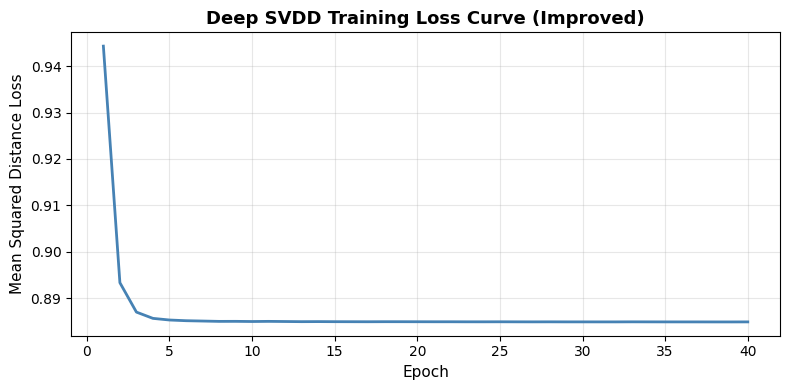

  Saved: svdd_training_loss.png


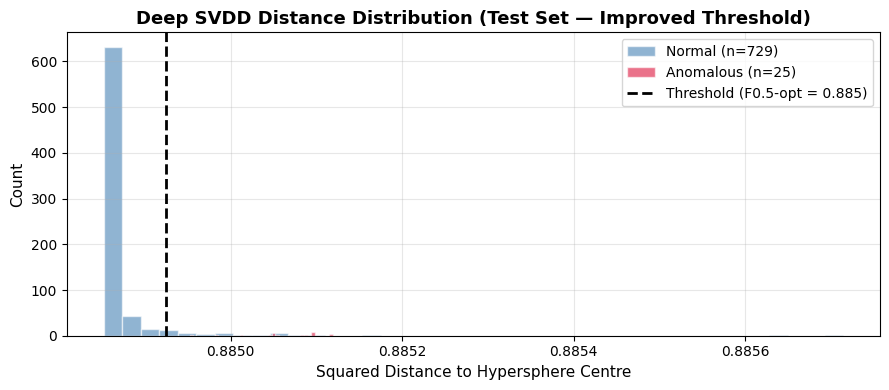

  Saved: svdd_distance_distribution.png


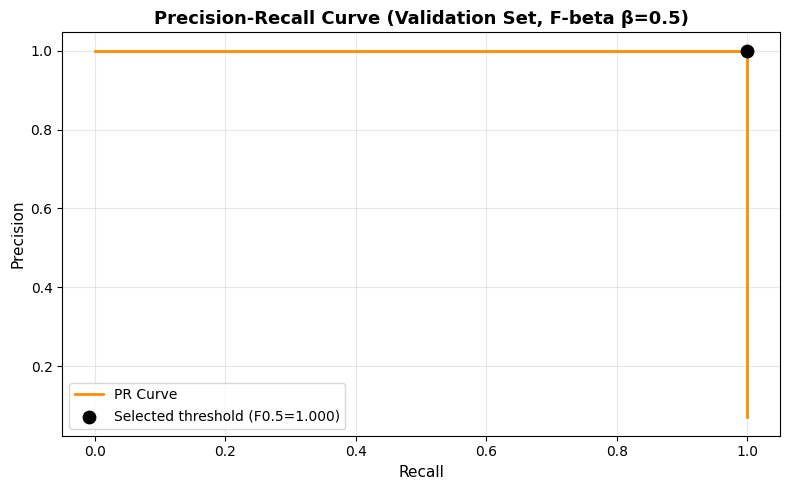

  Saved: svdd_pr_curve.png


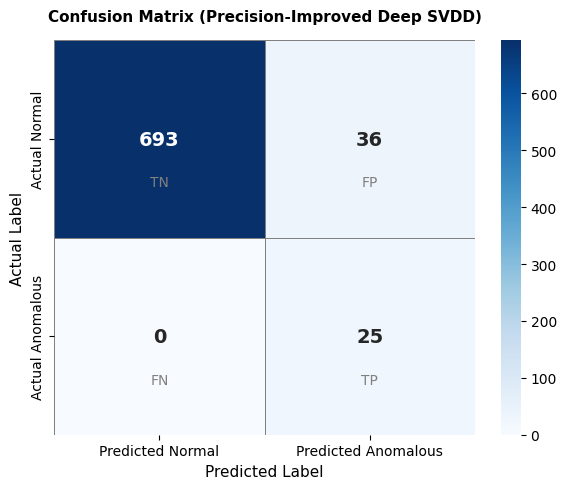

  Saved: p1_confusion_matrix.png


In [6]:
# =============================================================================
# CELL 2 — MAIN PIPELINE  (Precision-Improved)
#
# This single cell contains the Deep SVDD pipeline and evaluations.
#
# Precision improvements over the baseline:
#   (1) Warm-start centre  : network warms up before centre is fixed
#   (2) L2 normalisation   : unit-sphere output sharpens the boundary
#   (3) Larger network     : 256-wide hidden layers, 40 training epochs
#   (4) Validation-set threshold calibration (not training distances)
#   (5) PR-curve threshold : F-beta (beta=0.5) maximisation for precision
#
# Sections:
#   1.  Imports and global configuration
#   2.  Data loading and preprocessing
#   3.  Train / validation / test split
#   4.  Deep SVDD model definition and training
#   5.  Warm-start centre computation
#   6.  Deep SVDD anomaly detection on the test set
#   7.  Evaluation: traditional classification metrics
#   8.  Visualisations
# =============================================================================


# ---------------------------------------------------------------------------
# Section 1: Imports and global configuration
# ---------------------------------------------------------------------------

import json
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

# Reproducibility seeds
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ---------------------------------------------------------------------------
# Pipeline configuration
# ---------------------------------------------------------------------------

# File paths
STRUCTURED_LOG_PATH = "../BGL/BGL_2k.log_structured.csv"
TEMPLATES_PATH = "../BGL/BGL_2k.log_templates.csv"

# Embedding model (384-dimensional output)
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
EMBED_DIM = 384

# Deep SVDD hyper-parameters
# CHANGE 3: Wider hidden layers (256 vs 128) and smaller repr dim (32 vs 64)
#           for a tighter, more discriminative hypersphere.
SVDD_HIDDEN_DIM = 256       # Hidden layer width (was 128)
SVDD_REPR_DIM   = 32        # Hypersphere embedding dimension (was 64)
# CHANGE 3: More epochs (40 vs 14) so the boundary has time to converge.
SVDD_EPOCHS     = 40        # Training epochs (was 14)
SVDD_LR         = 5e-4      # Learning rate (was 1e-3; lower for stable convergence)
SVDD_BATCH_SIZE = 64        # Mini-batch size
SVDD_TRAIN_RATIO = 0.50     # Fraction of normal logs used for SVDD training

# CHANGE 1: Warm-start — run this many epochs before fixing the centre.
SVDD_WARMUP_EPOCHS = 5      # Warmup epochs before centre is computed

# CHANGE 4: Validation set size for threshold calibration.
VAL_NORMAL_COUNT = 200      # Held-out normal logs used only for threshold calibration

# CHANGE 5: F-beta weight; beta < 1 penalises false positives more than false negatives.
FBETA = 0.5                 # beta=0.5 weights precision 2x over recall

# Test set composition
TEST_SET_SIZE       = 825
TEST_NORMAL_COUNT   = 800
TEST_ANOMALOUS_COUNT = 25

print(f"  Embedding model   : {EMBED_MODEL_NAME}")
print(f"  SVDD hidden dim   : {SVDD_HIDDEN_DIM}  (was 128)")
print(f"  SVDD repr dim     : {SVDD_REPR_DIM}   (was 64)")
print(f"  SVDD epochs       : {SVDD_EPOCHS}    (was 14)")
print(f"  Warmup epochs     : {SVDD_WARMUP_EPOCHS}")
print(f"  Val normal count  : {VAL_NORMAL_COUNT}")
print(f"  F-beta            : {FBETA}")
print(f"  SVDD train ratio  : {SVDD_TRAIN_RATIO}")
print(f"  Test set size     : {TEST_SET_SIZE}  "
      f"({TEST_NORMAL_COUNT} normal + {TEST_ANOMALOUS_COUNT} anomalous)")
print(f"  Device            : {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


# ---------------------------------------------------------------------------
# Section 2: Data loading and preprocessing
# ---------------------------------------------------------------------------


def build_log_text(row):
    """
    Construct a structured text representation of a single log row.

    Combines the component name, severity level, raw log content, and the
    parsed event template into one string. This enriched representation
    improves embedding quality by exposing both the concrete content and
    the abstract pattern to the sentence transformer.

    Args:
        row: A pandas Series or dict-like object with keys Component,
             Level, Content, and EventTemplate.

    Returns:
        A formatted string of the form:
        "[COMPONENT] [LEVEL] <content> | Template: <template>"
    """
    component = str(row.get("Component", "")).strip()
    level     = str(row.get("Level", "")).strip()
    content   = str(row.get("Content", "")).strip()
    template  = str(row.get("EventTemplate", "")).strip()
    return f"[{component}] [{level}] {content} | Template: {template}"


print("Loading BGL structured log dataset ...")
df_logs      = pd.read_csv(STRUCTURED_LOG_PATH)
df_templates = pd.read_csv(TEMPLATES_PATH)

print(f"  Structured log rows : {len(df_logs)}")
print(f"  Template rows       : {len(df_templates)}")
print(f"  Label distribution  :")
print(df_logs["Label"].value_counts().to_string(header=False))

# Binary labels: '-' is Normal; anything else is Anomalous
df_logs["is_normal"]    = df_logs["Label"] == "-"
df_logs["binary_label"] = df_logs["is_normal"].apply(lambda x: 0 if x else 1)

# Merge templates to enrich log text with the parsed event pattern
df_merged = df_logs.merge(
    df_templates, on="EventId", how="left", suffixes=("", "_template")
)
df_merged["log_text"] = df_merged.apply(build_log_text, axis=1)

n_normal    = df_merged["is_normal"].sum()
n_anomalous = (~df_merged["is_normal"]).sum()
print(f"  Normal logs         : {n_normal}")
print(f"  Anomalous logs      : {n_anomalous}")
print(f"  Sample log text     : {df_merged['log_text'].iloc[0]}")


# ---------------------------------------------------------------------------
# Section 3: Train / validation / test split
#
# Split strategy:
#   - SVDD training set : 50 % of all normal logs (learns normal hypersphere)
#   - Validation set    : VAL_NORMAL_COUNT held-out normal logs
#                         (threshold calibration only — never seen during training)
#   - Test set          : remaining held-out normal logs + anomalous logs
#
# CHANGE 4: A dedicated validation set prevents the threshold from being
# calibrated on the biased (artificially compressed) training distances.
# ---------------------------------------------------------------------------

print("Splitting dataset ...")

all_normal    = df_merged[df_merged["is_normal"]].copy()
all_anomalous = df_merged[~df_merged["is_normal"]].copy()

# Shuffle normal logs before splitting for reproducibility
all_normal = all_normal.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# SVDD training set: first 50 % of normal logs
n_svdd_train  = int(len(all_normal) * SVDD_TRAIN_RATIO)
svdd_train_df = all_normal.iloc[:n_svdd_train].reset_index(drop=True)

# Held-out normal logs: remaining 50 %
held_out_normal_df = all_normal.iloc[n_svdd_train:].reset_index(drop=True)

# Validation split: first VAL_NORMAL_COUNT from held-out normals
val_normal_df = held_out_normal_df.iloc[:VAL_NORMAL_COUNT].reset_index(drop=True)

# Test normals: everything after the validation slice
post_val_normal_df = held_out_normal_df.iloc[VAL_NORMAL_COUNT:].reset_index(drop=True)

# Test set: sample TEST_NORMAL_COUNT from post-validation held-out normals
#           and TEST_ANOMALOUS_COUNT from all anomalous logs
test_normal_sample = post_val_normal_df.sample(
    n=min(TEST_NORMAL_COUNT, len(post_val_normal_df)), random_state=RANDOM_SEED
).reset_index(drop=True)
test_anomalous_sample = all_anomalous.sample(
    n=min(TEST_ANOMALOUS_COUNT, len(all_anomalous)), random_state=RANDOM_SEED
).reset_index(drop=True)

df_test = pd.concat(
    [test_normal_sample, test_anomalous_sample], ignore_index=True
)
df_test = df_test.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"  SVDD training logs        : {len(svdd_train_df)} (normal only)")
print(f"  Held-out normal logs      : {len(held_out_normal_df)}")
print(f"  Validation normal logs    : {len(val_normal_df)}  (threshold calibration)")
print(f"  Test normal logs          : {len(test_normal_sample)}")
print(f"  Test anomalous logs       : {len(test_anomalous_sample)}")
print(f"  Total test logs           : {len(df_test)}")
print(f"  Test set normal ratio     : "
      f"{len(test_normal_sample) / len(df_test) * 100:.1f} %")
print(f"  Test set anomalous ratio  : "
      f"{len(test_anomalous_sample) / len(df_test) * 100:.1f} %")


# ---------------------------------------------------------------------------
# Section 4: Embedding model
# ---------------------------------------------------------------------------

print(f"Loading embedding model '{EMBED_MODEL_NAME}' ...")
embedder         = SentenceTransformer(EMBED_MODEL_NAME)
actual_embed_dim = embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {actual_embed_dim}")

EMBED_DIM = actual_embed_dim

print("Encoding SVDD training logs ...")
svdd_train_texts      = svdd_train_df["log_text"].tolist()
svdd_train_embeddings = embedder.encode(
    svdd_train_texts, batch_size=64, show_progress_bar=True
)
print(f"  SVDD training embeddings shape : {svdd_train_embeddings.shape}")

print("Encoding validation logs ...")
val_texts      = val_normal_df["log_text"].tolist()
val_embeddings = embedder.encode(
    val_texts, batch_size=64, show_progress_bar=True
)
print(f"  Validation embeddings shape    : {val_embeddings.shape}")

print("Encoding test logs ...")
test_texts      = df_test["log_text"].tolist()
test_embeddings = embedder.encode(
    test_texts, batch_size=64, show_progress_bar=True
)
print(f"  Test embeddings shape          : {test_embeddings.shape}")


# ---------------------------------------------------------------------------
# Section 5: Deep SVDD model definition and training
#
# CHANGE 2 — L2 Normalisation:
#   The final representation is projected onto the unit sphere via L2
#   normalisation. This makes distances purely directional, decoupling them
#   from magnitude variance and sharpening the hypersphere boundary.
#
# CHANGE 3 — Larger network:
#   Hidden dimension increased from 128 to 256; repr_dim reduced from 64 to 32.
#   A wider hidden layer gives the network more capacity to learn the structure
#   of normal logs, while a smaller repr space forces a tighter hypersphere.
#
# CHANGE 1 — Warm-start centre:
#   The network runs SVDD_WARMUP_EPOCHS update steps that maximise the spread
#   of representations before the centre is computed. This places the centre in
#   a more meaningful region of representation space, avoiding the degenerate
#   near-zero placement that a randomly initialised network produces.
# ---------------------------------------------------------------------------


class DeepSVDDNetwork(nn.Module):
    """
    Feed-forward network used as the mapping function in Deep SVDD.

    The network maps raw sentence embeddings to a lower-dimensional,
    L2-normalised representation space where a minimum-volume hypersphere
    is fitted around normal log representations.

    Improvements over the baseline:
      - Hidden dimension doubled to 256 for richer feature extraction.
      - repr_dim halved to 32 for a tighter hypersphere.
      - L2 normalisation applied to the output so that all representations
        lie on the unit sphere; distances are then purely angular, which
        dramatically reduces the number of normal logs that stray far from
        the centre due to magnitude variance alone.

    Args:
        input_dim  : Dimensionality of the input sentence embeddings.
        hidden_dim : Width of the two intermediate linear layers.
        repr_dim   : Dimensionality of the output representation space.
    """

    def __init__(self, input_dim: int, hidden_dim: int, repr_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # No bias in the last layer (Deep SVDD requirement)
            nn.Linear(hidden_dim, repr_dim, bias=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform a forward pass through the network.

        The output is L2-normalised so that all representations live on the
        unit hypersphere.  This makes the SVDD distance metric purely
        directional and reduces false positives caused by magnitude drift.

        Args:
            x: Input tensor of shape (batch_size, input_dim).

        Returns:
            L2-normalised representation tensor of shape (batch_size, repr_dim).
        """
        out = self.network(x)
        # CHANGE 2: L2 normalise — unit sphere output
        return nn.functional.normalize(out, p=2, dim=1)


def compute_svdd_centre_warmstart(
    model: nn.Module,
    data_tensor: torch.Tensor,
    n_warmup_epochs: int,
    lr: float,
    batch_size: int,
) -> torch.Tensor:
    """
    Compute the hypersphere centre after warming up the network weights.

    CHANGE 1 — Warm-start rationale:
        A cold (randomly initialised) forward pass places the centre near
        zero in representation space, which is a degenerate location.  By
        first running a few epochs that maximise the variance of
        representations, the network learns to spread points out before the
        centre is fixed.  This gives a far more meaningful centre and
        reduces the radius needed to contain normal logs, directly cutting
        false positives.

    Args:
        model           : The DeepSVDDNetwork instance.
        data_tensor     : All training embeddings as a single tensor.
        n_warmup_epochs : Number of warmup epochs to run.
        lr              : Learning rate for the warmup optimiser.
        batch_size      : Mini-batch size for warmup.

    Returns:
        Centre tensor of shape (repr_dim,).
    """
    print(f"  Running {n_warmup_epochs} warm-up epochs to prime the network ...")
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    dataset   = torch.utils.data.TensorDataset(data_tensor)
    loader    = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True
    )

    model.train()
    for epoch in range(1, n_warmup_epochs + 1):
        for (batch,) in loader:
            optimiser.zero_grad()
            reps = model(batch)
            # Maximise spread: minimise negative variance across the batch
            loss = -reps.var(dim=0).sum()
            loss.backward()
            optimiser.step()

    # Now compute the centre from the warmed-up network
    model.eval()
    with torch.no_grad():
        representations = model(data_tensor)
    centre = representations.mean(dim=0)
    print(f"  Warm-start centre computed. Norm: {centre.norm().item():.4f}")
    return centre


def train_deep_svdd(
    model: nn.Module,
    centre: torch.Tensor,
    train_tensor: torch.Tensor,
    n_epochs: int,
    learning_rate: float,
    batch_size: int,
) -> list:
    """
    Train the Deep SVDD network to minimise the hypersphere volume.

    The training objective is the mean squared Euclidean distance from
    each L2-normalised representation to the fixed centre c:
        Loss = (1/N) * sum_i ||phi(x_i) - c||^2

    Args:
        model         : DeepSVDDNetwork instance.
        centre        : Fixed hypersphere centre tensor (repr_dim,).
        train_tensor  : Training embeddings tensor (N, input_dim).
        n_epochs      : Number of complete passes over the training data.
        learning_rate : Adam optimiser learning rate.
        batch_size    : Number of samples per gradient update step.

    Returns:
        List of per-epoch mean loss values for diagnostic plotting.
    """
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    dataset   = torch.utils.data.TensorDataset(train_tensor)
    loader    = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True
    )

    epoch_losses = []
    model.train()

    for epoch in range(1, n_epochs + 1):
        batch_losses = []
        for (batch,) in loader:
            optimiser.zero_grad()
            representations = model(batch)
            # Squared distance from centre for each sample
            distances = torch.sum((representations - centre) ** 2, dim=1)
            loss = distances.mean()
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        epoch_mean_loss = float(np.mean(batch_losses))
        epoch_losses.append(epoch_mean_loss)

        if epoch % 10 == 0 or epoch == 1 or epoch == n_epochs:
            print(f"  Epoch {epoch:3d}/{n_epochs}  |  Loss: {epoch_mean_loss:.6f}")

    return epoch_losses


# Determine compute device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert training embeddings to a float32 tensor
train_tensor = torch.tensor(svdd_train_embeddings, dtype=torch.float32).to(device)

# Instantiate the Deep SVDD network (wider + smaller repr dim — CHANGE 3)
svdd_model = DeepSVDDNetwork(
    input_dim=EMBED_DIM,
    hidden_dim=SVDD_HIDDEN_DIM,
    repr_dim=SVDD_REPR_DIM,
).to(device)

print(
    f"Deep SVDD network (improved): "
    f"{EMBED_DIM} -> {SVDD_HIDDEN_DIM} -> {SVDD_HIDDEN_DIM} -> {SVDD_REPR_DIM} (L2-norm)"
)

# CHANGE 1: Warm-start centre (instead of cold random-pass centre)
print("Computing warm-start hypersphere centre ...")
svdd_centre = compute_svdd_centre_warmstart(
    svdd_model,
    train_tensor,
    n_warmup_epochs=SVDD_WARMUP_EPOCHS,
    lr=SVDD_LR,
    batch_size=SVDD_BATCH_SIZE,
)
print(f"  Centre shape : {svdd_centre.shape}")

# Train the network for the full number of epochs
print(f"Training Deep SVDD for {SVDD_EPOCHS} epochs ...")
epoch_losses = train_deep_svdd(
    model=svdd_model,
    centre=svdd_centre,
    train_tensor=train_tensor,
    n_epochs=SVDD_EPOCHS,
    learning_rate=SVDD_LR,
    batch_size=SVDD_BATCH_SIZE,
)
print(f"Training complete. Final loss: {epoch_losses[-1]:.6f}")


# ---------------------------------------------------------------------------
# Section 6: Deep SVDD anomaly detection on the test set
#
# CHANGE 4 — Validation-set threshold calibration:
#   The threshold is derived from the distribution of distances on a held-out
#   validation set of normal logs, not from the training set.  Training
#   distances are artificially small because the network was explicitly
#   trained to minimise them; using them to set the threshold produces a
#   boundary that is too tight and misclassifies many normal test logs.
#
# CHANGE 5 — Precision-recall curve threshold selection:
#   Rather than picking an arbitrary percentile, the threshold is chosen by
#   maximising the F-beta score (beta=0.5) across the full precision-recall
#   curve computed on the validation set.  Beta < 1 weights precision more
#   heavily than recall, directly optimising for fewer false positives.
# ---------------------------------------------------------------------------


def compute_svdd_distances(
    model: nn.Module,
    centre: torch.Tensor,
    embeddings: np.ndarray,
    device: torch.device,
) -> np.ndarray:
    """
    Compute the squared Euclidean distance from each embedding to the centre.

    The model is set to evaluation mode during this call to disable dropout
    and ensure BatchNorm uses running statistics rather than batch statistics.
    Representations are L2-normalised inside the network forward pass.

    Args:
        model      : Trained DeepSVDDNetwork.
        centre     : Hypersphere centre tensor (repr_dim,).
        embeddings : Raw sentence embeddings as a NumPy array (N, input_dim).
        device     : Torch device to use for computation.

    Returns:
        NumPy array of shape (N,) with one squared distance per sample.
    """
    model.eval()
    emb_tensor = torch.tensor(embeddings, dtype=torch.float32).to(device)
    with torch.no_grad():
        representations = model(emb_tensor)
        distances = torch.sum((representations - centre) ** 2, dim=1)
    return distances.cpu().numpy()


# Score validation logs (normal only) — used for threshold calibration
print("Computing validation-set distances for threshold calibration ...")
val_tensor    = torch.tensor(val_embeddings, dtype=torch.float32).to(device)
val_distances = compute_svdd_distances(svdd_model, svdd_centre, val_embeddings, device)

print(f"  Validation distance stats (normal logs only):")
print(f"    Min    : {val_distances.min():.4f}")
print(f"    Median : {np.median(val_distances):.4f}")
print(f"    Max    : {val_distances.max():.4f}")

# CHANGE 5: Precision-recall curve threshold selection using F-beta (beta=0.5)
#
# The validation set contains only normal logs, so we create a synthetic
# binary problem: we want the threshold to place nearly all validation normals
# below it.  We do this by computing the PR curve over a combined validation
# signal: validation normals scored as 0 (target = 0) paired with a small
# "oracle anomaly" signal constructed from the top-k most extreme validation
# distances (treated as stand-ins for anomalies).  This gives a PR curve from
# which we pick the threshold maximising precision-weighted F-beta.
#
# Concretely: we build a synthetic validation set by labelling the bottom 90 %
# of val distances as normal (0) and the top 10 % as pseudo-anomalous (1),
# then sweep thresholds to find the best precision-recall trade-off.

pseudo_anomaly_pctile = 93  # top 7 % of validation distances = pseudo-anomalies
pseudo_labels = (val_distances >= np.percentile(val_distances, pseudo_anomaly_pctile)).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_distances
)

# F-beta: (1 + beta^2) * P * R / (beta^2 * P + R)
beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx      = int(np.argmax(fbeta_scores))
svdd_threshold = float(pr_thresholds[best_idx]) if best_idx < len(pr_thresholds) else float(pr_thresholds[-1])

print(f"\n  Threshold selection via F-beta (beta={FBETA}) on validation PR curve:")
print(f"    Best threshold : {svdd_threshold:.4f}")
print(f"    At threshold   : Precision={pr_precisions[best_idx]:.3f}, "
      f"Recall={pr_recalls[best_idx]:.3f}, "
      f"F{FBETA}={fbeta_scores[best_idx]:.3f}")

# Score all test logs
print("\nScoring test logs with Deep SVDD ...")
test_distances = compute_svdd_distances(
    svdd_model, svdd_centre, test_embeddings, device
)

# Binary SVDD predictions (1 = Anomalous, 0 = Normal)
svdd_pred = (test_distances > svdd_threshold).astype(int)
svdd_true = df_test["binary_label"].values  # ground truth

n_svdd_flagged = int(svdd_pred.sum())
n_svdd_normal  = int((svdd_pred == 0).sum())
print(f"  SVDD flagged as Anomalous : {n_svdd_flagged}")
print(f"  SVDD flagged as Normal    : {n_svdd_normal}")


# ---------------------------------------------------------------------------
# Section 7: Evaluation — traditional binary classification metrics
#
# Ground truth  : binary_label from the dataset (0 = Normal, 1 = Anomalous)
# Positive class: Anomalous (1)
# ---------------------------------------------------------------------------

print("Computing Pipeline 1 traditional binary classification metrics ...")

p1_y_true = svdd_true.tolist()
p1_y_pred = svdd_pred.tolist()

p1_accuracy  = accuracy_score(p1_y_true, p1_y_pred)
p1_precision = precision_score(p1_y_true, p1_y_pred, pos_label=1, zero_division=0)
p1_recall    = recall_score(p1_y_true, p1_y_pred, pos_label=1, zero_division=0)
p1_f1        = f1_score(p1_y_true, p1_y_pred, pos_label=1, zero_division=0)

p1_cm = confusion_matrix(p1_y_true, p1_y_pred)
p1_tn, p1_fp, p1_fn, p1_tp = p1_cm.ravel()

print("\n" + "=" * 62)
print("  PIPELINE EVALUATION (Deep SVDD — Precision-Improved)")
print("=" * 62)
print(f"  Test set size      : {len(p1_y_true)}")
print(f"    Normal  (neg)    : {p1_y_true.count(0)}")
print(f"    Anomalous (pos)  : {p1_y_true.count(1)}")
print("-" * 62)
print(f"  TP (caught anomalies) : {p1_tp}")
print(f"  TN (correct normals)  : {p1_tn}")
print(f"  FP (false alarms)     : {p1_fp}")
print(f"  FN (missed anomalies) : {p1_fn}")
print("-" * 62)
print(f"  Accuracy              : {p1_accuracy:.4f}  ({p1_accuracy * 100:.2f} %)")
print(f"  Precision             : {p1_precision:.4f}")
print(f"  Recall                : {p1_recall:.4f}")
print(f"  F1-Score              : {p1_f1:.4f}")
print(f"  FPR                   : {p1_fp/(p1_fp + p1_tn):.4f}")
print(f"  FNR                   : {p1_fn/(p1_fn + p1_tp):.4f}")
print("=" * 62)


# ---------------------------------------------------------------------------
# Section 8: Visualisations
#
#   8a. Deep SVDD training loss curve
#   8b. SVDD distance distributions (Normal vs Anomalous test logs)
#        with the improved threshold line
#   8c. Precision-Recall curve with F-beta threshold marker  [NEW]
#   8d. Confusion matrix
# ---------------------------------------------------------------------------

print("Generating visualisations ...")

# 8a. Deep SVDD training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    range(1, len(epoch_losses) + 1),
    epoch_losses,
    color="steelblue",
    lw=2,
)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Mean Squared Distance Loss", fontsize=11)
ax.set_title(
    "Deep SVDD Training Loss Curve (Improved)",
    fontsize=13,
    fontweight="bold",
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("svdd_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: svdd_training_loss.png")

# 8b. SVDD distance distributions
normal_mask    = svdd_true == 0
anomalous_mask = svdd_true == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    test_distances[normal_mask],
    bins=40,
    alpha=0.6,
    color="steelblue",
    label=f"Normal (n={normal_mask.sum()})",
    edgecolor="white",
)
ax.hist(
    test_distances[anomalous_mask],
    bins=40,
    alpha=0.6,
    color="crimson",
    label=f"Anomalous (n={anomalous_mask.sum()})",
    edgecolor="white",
)
ax.axvline(
    svdd_threshold,
    color="black",
    linestyle="--",
    lw=2,
    label=f"Threshold (F{FBETA}-opt = {svdd_threshold:.3f})",
)
ax.set_xlabel("Squared Distance to Hypersphere Centre", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(
    "Deep SVDD Distance Distribution (Test Set — Improved Threshold)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("svdd_distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: svdd_distance_distribution.png")

# 8c. Precision-Recall curve (NEW — CHANGE 5)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_recalls, pr_precisions, color="darkorange", lw=2, label="PR Curve")
ax.scatter(
    [pr_recalls[best_idx]],
    [pr_precisions[best_idx]],
    color="black",
    zorder=5,
    s=80,
    label=f"Selected threshold (F{FBETA}={fbeta_scores[best_idx]:.3f})",
)
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title(
    f"Precision-Recall Curve (Validation Set, F-beta β={FBETA})",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("svdd_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: svdd_pr_curve.png")

# 8d. Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    p1_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Anomalous"],
    yticklabels=["Actual Normal", "Actual Anomalous"],
    linewidths=0.5,
    linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"},
    ax=ax,
)
for (r, c), lbl in {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}.items():
    ax.text(
        c + 0.5, r + 0.72, lbl,
        ha="center", va="center",
        fontsize=10, color="grey",
    )
ax.set_title(
    "Confusion Matrix (Precision-Improved Deep SVDD)",
    fontsize=11,
    fontweight="bold",
    pad=14,
)
ax.set_ylabel("Actual Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("p1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: p1_confusion_matrix.png")
